# Fases 3 y 4 — Feature Engineering y Segmentacion de Clientes (K-Means)

**Proyecto:** Analisis de Ventas 2020-2023 — Prueba Tecnica Summan
**Autor:** Sebastian Lesmes | **Fecha:** Abril 2026

---

### Estructura
| Fase | Contenido |
|---|---|
| **3.1** | Carga de datos desde MariaDB |
| **3.2** | Variables RFM (Recency, Frequency, Monetary) |
| **3.3** | Variables conductuales derivadas de Sales |
| **3.4** | Variables socioeconomicas de Customer |
| **3.5** | Tabla plana consolidada por cliente |
| **3.6** | Encoding + escalado (StandardScaler) |
| **3.7** | Exportar flat table a CSV y MariaDB |
| **4.1** | Numero optimo de clusters (Elbow + Silhouette) |
| **4.2** | Entrenamiento K-Means |
| **4.3** | Interpretacion y nombrado de segmentos |
| **4.4** | Visualizaciones de segmentos |
| **4.5** | Exportar segmentos a CSV y MariaDB |


## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110})

# ── Credenciales MariaDB  ─────────────────────────────────────────────────────
load_dotenv()  # Carga variables de entorno desde .env
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/sales_db", echo=False)

def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("Conexion a sales_db establecida")


Conexion a sales_db establecida


---
## FASE 3 — Feature Engineering

### 3.1 Carga de datos desde MariaDB

In [2]:
df_sales = query("SELECT * FROM fact_sales")
df_cust  = query("SELECT * FROM dim_customer")
df_prod  = query("SELECT * FROM dim_product")
df_ret   = query("SELECT * FROM dim_returns")

df_sales['Order_Date'] = pd.to_datetime(df_sales['Order_Date'])
df_sales['Ship_Date']  = pd.to_datetime(df_sales['Ship_Date'])

# Unir producto y devolucion a ventas
df = (df_sales
      .merge(df_prod[['Product_ID','Category','Sub-Category']], on='Product_ID', how='left')
      .merge(df_ret[['Order_ID']].assign(is_returned=1), on='Order_ID', how='left'))
df['is_returned'] = df['is_returned'].fillna(0).astype(int)

print(f"Tabla base: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Clientes unicos: {df['Customer_ID'].nunique():,}")
print(f"Periodo: {df['Order_Date'].min().date()} -> {df['Order_Date'].max().date()}")


Tabla base: 10,529 filas x 19 columnas
Clientes unicos: 804
Periodo: 2020-01-03 -> 2023-12-30


### 3.2 Variables RFM

- **Recency**: dias desde la ultima compra hasta el ultimo registro del dataset
- **Frequency**: numero de ordenes unicas
- **Monetary**: suma total de ventas (USD)


In [3]:
# Fecha de referencia = max fecha del dataset + 1 dia
ref_date = df['Order_Date'].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia (snapshot): {ref_date.date()}")

rfm = (df.groupby('Customer_ID')
         .agg(
             recency   = ('Order_Date',  lambda x: (ref_date - x.max()).days),
             frequency = ('Order_ID',    'nunique'),
             monetary  = ('Sales',       'sum'),
         )
         .reset_index())

print("\nRFM — estadisticas descriptivas:")
print(rfm[['recency','frequency','monetary']].describe().round(2).to_string())


Fecha de referencia (snapshot): 2023-12-31

RFM — estadisticas descriptivas:
        recency  frequency   monetary
count  804.0000   804.0000   804.0000
mean   147.0100     6.3600  3012.7200
std    185.5300     2.6600  2778.6900
min      1.0000     1.0000     4.8300
25%     30.0000     5.0000  1135.6200
50%     76.0000     6.0000  2280.0800
75%    181.7500     8.0000  3894.1200
max   1165.0000    17.0000 25073.8200


### 3.3 Variables conductuales derivadas de Sales

Variables que capturan el *comportamiento de compra* de cada cliente.

In [4]:
# ── avg_discount y avg_profit_per_order ─────────────────────────────────────
behav = df.groupby('Customer_ID').agg(
    avg_discount        = ('Discount',    'mean'),
    avg_profit_per_order= ('Profit',      lambda x: x.sum() / df.loc[x.index, 'Order_ID'].nunique()),
    return_rate         = ('is_returned', 'mean'),
    avg_quantity        = ('Quantity',    'mean'),
    total_orders        = ('Order_ID',    'nunique'),
).reset_index()

print("Variables conductuales basicas:")
print(behav.describe().round(4).to_string())


Variables conductuales basicas:
       avg_discount  avg_profit_per_order  return_rate  avg_quantity  total_orders
count      804.0000              804.0000     804.0000      804.0000      804.0000
mean         0.1575               56.6082       0.0743        3.7857        6.3595
std          0.0928              160.6307       0.1460        0.7598        2.6599
min          0.0000            -1369.5530       0.0000        1.0000        1.0000
25%          0.0909                9.7842       0.0000        3.3150        5.0000
50%          0.1500               40.7597       0.0000        3.7500        6.0000
75%          0.2126               91.2937       0.1000        4.2163        8.0000
max          0.7000             1802.0364       1.0000        8.0000       17.0000


In [5]:
# ── preferred_category y preferred_region ───────────────────────────────────
pref_cat = (df.groupby(['Customer_ID','Category'])
              .size()
              .reset_index(name='cnt')
              .sort_values('cnt', ascending=False)
              .drop_duplicates('Customer_ID')
              .rename(columns={'Category': 'preferred_category'})
              [['Customer_ID','preferred_category']])

pref_reg = (df.groupby(['Customer_ID','Region'])
              .size()
              .reset_index(name='cnt')
              .sort_values('cnt', ascending=False)
              .drop_duplicates('Customer_ID')
              .rename(columns={'Region': 'preferred_region'})
              [['Customer_ID','preferred_region']])

print("Categorias preferidas:")
print(pref_cat['preferred_category'].value_counts().to_string())
print("\nRegiones preferidas:")
print(pref_reg['preferred_region'].value_counts().to_string())


Categorias preferidas:
preferred_category
Office Supplies    699
Furniture           75
Technology          30

Regiones preferidas:
preferred_region
West       294
East       258
Central    138
South      114


In [6]:
# ── avg_order_gap: promedio de dias entre compras consecutivas ───────────────
# Calcular a nivel de orden unica (no de linea de venta)
order_dates = (df.groupby(['Customer_ID','Order_ID'])['Order_Date']
                 .min()
                 .reset_index()
                 .sort_values(['Customer_ID','Order_Date']))

def mean_gap(dates):
    if len(dates) < 2:
        return np.nan
    diffs = dates.diff().dt.days.dropna()
    return diffs.mean()

gap_df = (order_dates
          .groupby('Customer_ID')['Order_Date']
          .apply(mean_gap)
          .reset_index(name='avg_order_gap'))

# Clientes con una sola orden: gap = NaN -> imputar con la mediana del grupo
median_gap = gap_df['avg_order_gap'].median()
gap_df['avg_order_gap'] = gap_df['avg_order_gap'].fillna(median_gap)

print(f"avg_order_gap — media: {gap_df['avg_order_gap'].mean():.1f} dias  "
      f"mediana: {gap_df['avg_order_gap'].median():.1f} dias")
print(f"Clientes con una sola orden (gap imputado con mediana): "
      f"{(order_dates.groupby('Customer_ID').size() == 1).sum()}")


avg_order_gap — media: 225.7 dias  mediana: 192.1 dias
Clientes con una sola orden (gap imputado con mediana): 12


In [7]:
# ── discount_impact: sensibilidad al descuento ──────────────────────────────
# Ratio: cantidad_promedio_con_descuento / cantidad_promedio_sin_descuento
# Ratio > 1 => cliente compra MAS unidades cuando hay descuento

def discount_impact(sub):
    with_disc    = sub[sub['Discount'] > 0]['Quantity'].mean()
    without_disc = sub[sub['Discount'] == 0]['Quantity'].mean()
    if pd.isna(without_disc) or without_disc == 0:
        return 1.0   # sin referencia: neutro
    if pd.isna(with_disc):
        return 1.0   # nunca compra con descuento: neutro
    return with_disc / without_disc

disc_impact_df = (df.groupby('Customer_ID')
                    .apply(discount_impact, include_groups=False)
                    .reset_index(name='discount_impact'))

print(f"discount_impact — media: {disc_impact_df['discount_impact'].mean():.3f}")
print(f"  >1 (compra mas con descuento): {(disc_impact_df['discount_impact'] > 1).sum():,} clientes")
print(f"  <1 (compra menos con descuento): {(disc_impact_df['discount_impact'] < 1).sum():,} clientes")
print(f"  =1 (sin diferencia): {(disc_impact_df['discount_impact'] == 1).sum():,} clientes")


discount_impact — media: 1.069
  >1 (compra mas con descuento): 342 clientes
  <1 (compra menos con descuento): 386 clientes
  =1 (sin diferencia): 76 clientes


### 3.4 Variables socioeconomicas de Customer

In [8]:
socio = df_cust[['Customer_ID','monthly_salary','age','marital_status','credit_score']].copy()
socio['monthly_salary'] = pd.to_numeric(socio['monthly_salary'], errors='coerce')
socio['marital_status'] = pd.to_numeric(socio['marital_status'], errors='coerce')

print("Variables socioeconomicas — nulos:")
print(socio.isnull().sum().to_string())
print(f"\nClientes en dim_customer: {len(socio):,}")


Variables socioeconomicas — nulos:
Customer_ID       0
monthly_salary    0
age               0
marital_status    5
credit_score      0

Clientes en dim_customer: 804


### 3.5 Tabla plana consolidada por cliente

Un cliente = una fila con todas sus variables.

In [9]:
df_flat = (rfm
           .merge(behav,          on='Customer_ID', how='left')
           .merge(pref_cat,       on='Customer_ID', how='left')
           .merge(pref_reg,       on='Customer_ID', how='left')
           .merge(gap_df,         on='Customer_ID', how='left')
           .merge(disc_impact_df, on='Customer_ID', how='left')
           .merge(socio,          on='Customer_ID', how='left'))

print(f"Tabla plana: {df_flat.shape[0]:,} clientes x {df_flat.shape[1]} variables")
print("\nColumnas:", list(df_flat.columns))
print("\nNulos por columna:")
print(df_flat.isnull().sum()[df_flat.isnull().sum() > 0].to_string())


Tabla plana: 804 clientes x 17 variables

Columnas: ['Customer_ID', 'recency', 'frequency', 'monetary', 'avg_discount', 'avg_profit_per_order', 'return_rate', 'avg_quantity', 'total_orders', 'preferred_category', 'preferred_region', 'avg_order_gap', 'discount_impact', 'monthly_salary', 'age', 'marital_status', 'credit_score']

Nulos por columna:
marital_status    5


In [10]:
# Imputar nulos residuales con la mediana de cada columna numerica
num_cols = df_flat.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    if df_flat[col].isnull().sum() > 0:
        med = df_flat[col].median()
        df_flat[col] = df_flat[col].fillna(med)
        print(f"  {col}: {df_flat[col].isnull().sum()} nulos imputados con mediana={med:.2f}")

print("\nNulos restantes:", df_flat.isnull().sum().sum())
print(f"\nEstadisticas finales de la tabla plana:")
print(df_flat[num_cols].describe().round(3).to_string())


  marital_status: 0 nulos imputados con mediana=1.00

Nulos restantes: 0

Estadisticas finales de la tabla plana:
        recency  frequency   monetary  avg_discount  avg_profit_per_order  return_rate  avg_quantity  total_orders  avg_order_gap  discount_impact  monthly_salary      age  marital_status  credit_score
count  804.0000   804.0000   804.0000      804.0000              804.0000     804.0000      804.0000      804.0000       804.0000         804.0000        804.0000 804.0000        804.0000      804.0000
mean   147.0120     6.3590  3012.7190        0.1580               56.6080       0.0740        3.7860        6.3590       225.7370           1.0690       6029.3500  38.0000          0.5200      557.9480
std    185.5320     2.6600  2778.6850        0.0930              160.6310       0.1460        0.7600        2.6600       134.6690           0.4700       2298.4100   7.1480          0.5000      148.9920
min      1.0000     1.0000     4.8330        0.0000            -1369.5530     

In [11]:
# Winsorización al p70 — monetary y avg_profit_per_order
# Evita que outliers extremos dominen la distancia euclidiana en K-Means
# Se aplica sobre df_flat ANTES del escalado; los datos originales en MariaDB no se modifican

WIN_COLS_03 = ['monetary', 'avg_profit_per_order']
WIN_P = 0.70

print('Winsorización p70 sobre flat table:')
for col in WIN_COLS_03:
    if col in df_flat.columns:
        p70 = df_flat[col].quantile(WIN_P)
        n   = (df_flat[col] > p70).sum()
        df_flat[col] = df_flat[col].clip(upper=p70)
        print(f'  {col:<28}: cap={p70:>10,.2f}  registros afectados={n}')

print(f'\nMonetary max post-winsorización : ${df_flat["monetary"].max():,.2f}')
print(f'avg_profit max post-winsorización: ${df_flat["avg_profit_per_order"].max():,.2f}')

Winsorización p70 sobre flat table:
  monetary                    : cap=  3,419.79  registros afectados=241
  avg_profit_per_order        : cap=     75.49  registros afectados=241

Monetary max post-winsorización : $3,419.79
avg_profit max post-winsorización: $75.49


### 3.6 Encoding de categoricas y escalado (StandardScaler)

K-Means usa distancias euclidianas — todas las variables deben estar en la misma escala.

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Label Encoding para variables categoricas
le_cat = LabelEncoder()
le_reg = LabelEncoder()

df_flat['preferred_category_enc'] = le_cat.fit_transform(df_flat['preferred_category'].astype(str))
df_flat['preferred_region_enc']   = le_reg.fit_transform(df_flat['preferred_region'].astype(str))

print("Encoding de categorias:")
for i, c in enumerate(le_cat.classes_): print(f"  {c} -> {i}")
print("Encoding de regiones:")
for i, r in enumerate(le_reg.classes_): print(f"  {r} -> {i}")


Encoding de categorias:
  Furniture -> 0
  Office Supplies -> 1
  Technology -> 2
Encoding de regiones:
  Central -> 0
  East -> 1
  South -> 2
  West -> 3


In [13]:
# Seleccionar features para el clustering
FEATURES = [
    # RFM
    'recency', 'frequency', 'monetary',
    # Conductuales
    'avg_discount', 'avg_profit_per_order', 'return_rate',
    'avg_quantity', 'avg_order_gap', 'discount_impact',
    # Categoricas codificadas
    'preferred_category_enc', 'preferred_region_enc',
    # Socioeconomicas
    'monthly_salary', 'age', 'marital_status', 'credit_score',
]

X = df_flat[FEATURES].copy()
print(f"Features para clustering: {len(FEATURES)}")
print(FEATURES)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=df_flat.index)

print(f"\nMedia post-escalado (debe ser ~0): {X_scaled_df.mean().abs().max():.6f}")
print(f"Std  post-escalado (debe ser ~1): {X_scaled_df.std().min():.4f} - {X_scaled_df.std().max():.4f}")


Features para clustering: 15
['recency', 'frequency', 'monetary', 'avg_discount', 'avg_profit_per_order', 'return_rate', 'avg_quantity', 'avg_order_gap', 'discount_impact', 'preferred_category_enc', 'preferred_region_enc', 'monthly_salary', 'age', 'marital_status', 'credit_score']

Media post-escalado (debe ser ~0): 0.000000
Std  post-escalado (debe ser ~1): 1.0006 - 1.0006


### 3.7 Exportar tabla plana a CSV y MariaDB

In [14]:
# CSV
df_flat.to_csv('../data/processed/flat_table_model.csv', index=False)
print("Guardado: data/processed/flat_table_model.csv")

# MariaDB
df_flat.to_sql('customer_flat_table', engine, if_exists='replace', index=False, chunksize=200)
print("Cargado: sales_db.customer_flat_table")
print(f"Shape exportado: {df_flat.shape}")


Guardado: data/processed/flat_table_model.csv
Cargado: sales_db.customer_flat_table
Shape exportado: (804, 19)


---
## FASE 4 — Modelo de Segmentacion K-Means

### 4.1 Numero optimo de clusters

Dos metricas complementarias:
- **Inertia (metodo del codo):** mide la compacidad interna. Buscar el "codo".
- **Silhouette Score:** mide separacion entre clusters. Maximizar (rango: -1 a 1).


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias     = []
silhouettes  = []
K_RANGE      = range(2, 11)

print("Calculando metricas para k=2..10 (puede tardar ~30 seg)...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

print("\nListo.")


Calculando metricas para k=2..10 (puede tardar ~30 seg)...
  k=2  inertia=10,804  silhouette=0.1249
  k=3  inertia=10,273  silhouette=0.1161
  k=4  inertia=9,781  silhouette=0.0593
  k=5  inertia=9,411  silhouette=0.0665
  k=6  inertia=9,027  silhouette=0.0705
  k=7  inertia=8,687  silhouette=0.0777
  k=8  inertia=8,460  silhouette=0.0737
  k=9  inertia=8,128  silhouette=0.0735
  k=10  inertia=7,947  silhouette=0.0727

Listo.


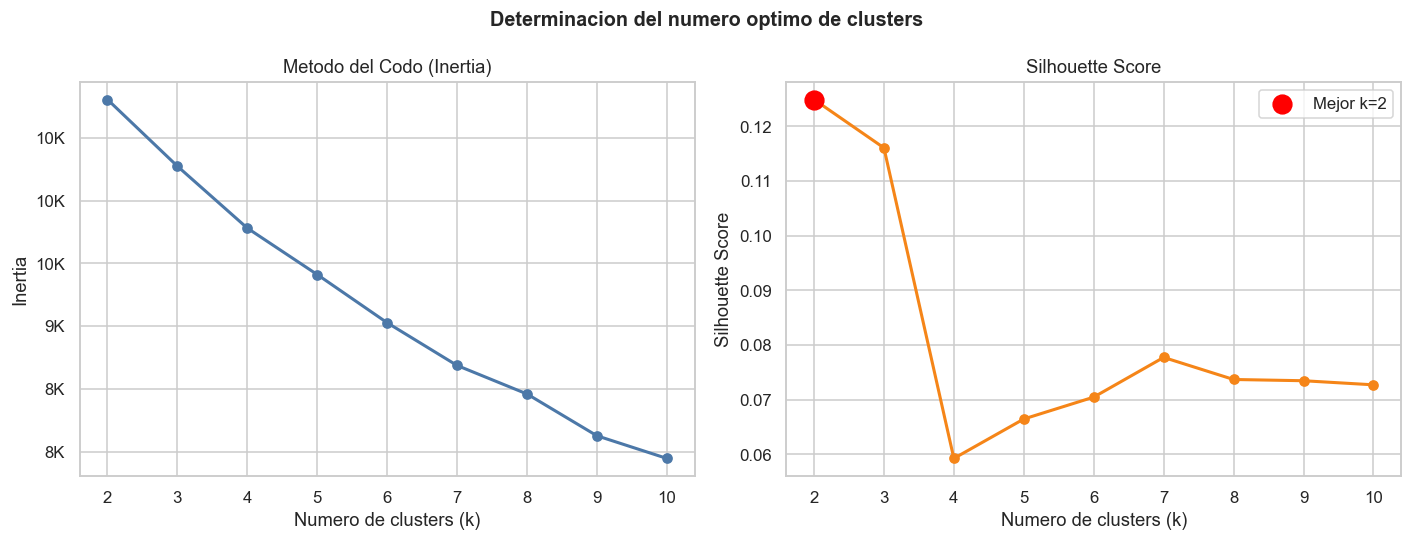

Silhouette maximo: 0.1249 en k=2
Revisar el grafico del codo para confirmar o ajustar k.


In [16]:
# Graficar Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Determinacion del numero optimo de clusters', fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(list(K_RANGE), inertias, marker='o', color='#4C78A8', linewidth=2)
axes[0].set_title('Metodo del Codo (Inertia)')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Silhouette
best_k_idx = int(np.argmax(silhouettes))
axes[1].plot(list(K_RANGE), silhouettes, marker='o', color='#F58518', linewidth=2)
axes[1].scatter(list(K_RANGE)[best_k_idx], silhouettes[best_k_idx],
                color='red', s=150, zorder=5, label=f'Mejor k={list(K_RANGE)[best_k_idx]}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/seg_01_elbow_silhouette.png', bbox_inches='tight')
plt.show()

print(f"Silhouette maximo: {max(silhouettes):.4f} en k={list(K_RANGE)[best_k_idx]}")
print("Revisar el grafico del codo para confirmar o ajustar k.")


In [17]:
# Seleccionar K_OPTIMO: mejor silhouette con minimo 4 para utilidad de negocio
K_OPTIMO = list(K_RANGE)[silhouettes.index(max(silhouettes))]

if K_OPTIMO < 4:
    print(f"k optimo estadistico ({K_OPTIMO}) < 4; se fuerza K_OPTIMO=4 (interpretabilidad de negocio)")
    K_OPTIMO = 4

print(f"K_OPTIMO seleccionado: {K_OPTIMO}")

k optimo estadistico (2) < 4; se fuerza K_OPTIMO=4 (interpretabilidad de negocio)
K_OPTIMO seleccionado: 4


### 4.2 Entrenamiento del modelo K-Means

In [18]:
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_flat['segment'] = kmeans.fit_predict(X_scaled)

print(f"K-Means entrenado con k={K_OPTIMO}")
print("\nDistribucion de clientes por segmento:")
dist = df_flat['segment'].value_counts().sort_index()
for seg, cnt in dist.items():
    pct = cnt / len(df_flat) * 100
    bar = '#' * int(pct / 2)
    print(f"  Segmento {seg}: {cnt:>4} clientes ({pct:.1f}%)  {bar}")


K-Means entrenado con k=4

Distribucion de clientes por segmento:
  Segmento 0:   83 clientes (10.3%)  #####
  Segmento 1:  233 clientes (29.0%)  ##############
  Segmento 2:  226 clientes (28.1%)  ##############
  Segmento 3:  262 clientes (32.6%)  ################


### 4.3 Interpretacion y nombrado de segmentos

Analizar el perfil promedio de cada cluster en las variables mas importantes.
Luego asignar un nombre de negocio.

In [19]:
# Perfil promedio por segmento
KEY_VARS = ['recency','frequency','monetary','avg_discount',
            'avg_profit_per_order','return_rate','monthly_salary',
            'age','credit_score','discount_impact','avg_order_gap']

profile = df_flat.groupby('segment')[KEY_VARS].mean().round(3)
print("Perfil promedio por segmento:")
print(profile.T.to_string())


Perfil promedio por segmento:
segment                      0         1         2         3
recency               467.6750   89.0860  145.8940   97.9080
frequency               3.6990    7.9740    4.1500    7.6720
monetary             1448.3770 2837.2420  996.1990 2817.5770
avg_discount            0.2610    0.1520    0.1380    0.1460
avg_profit_per_order  -89.2030   39.3720   28.4730   38.7030
return_rate             0.0350    0.0630    0.0990    0.0750
monthly_salary       5313.6630 6297.0130 6225.6810 5848.6830
age                    37.9400   38.6310   37.2480   38.1070
credit_score          586.5060  575.7940  551.0180  539.0080
discount_impact         1.1490    1.0060    1.1560    1.0240
avg_order_gap         248.0470  170.7160  334.6710  173.6360


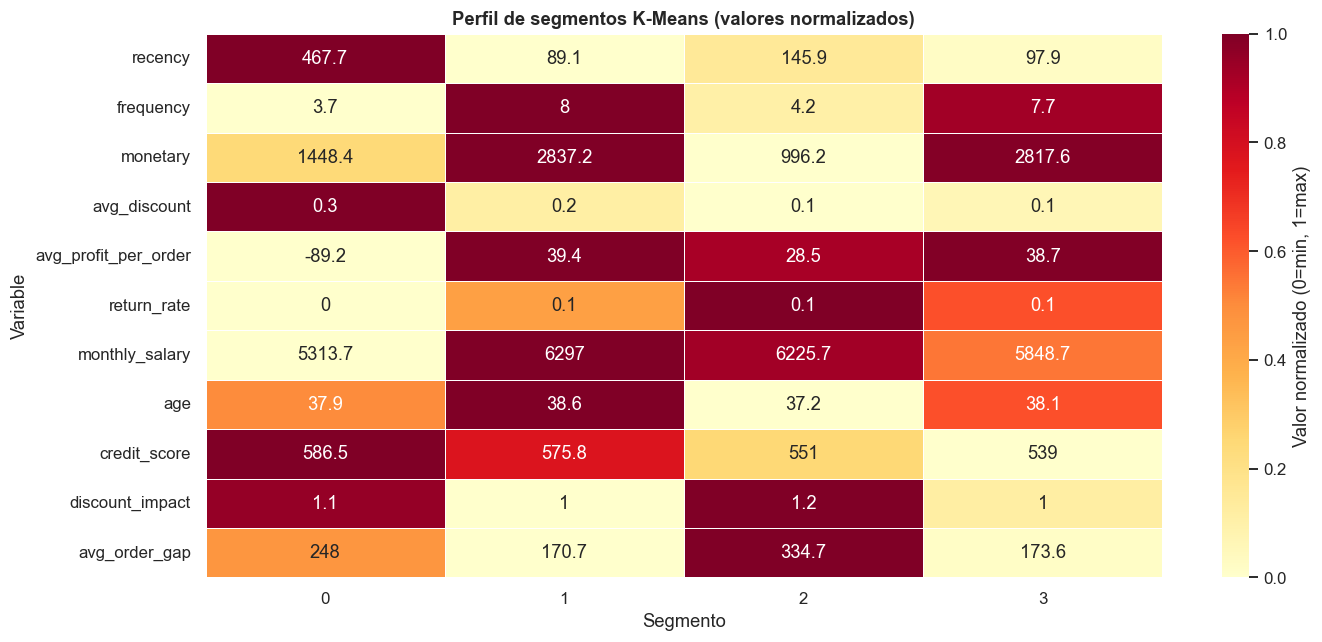

In [20]:
# Normalizar el perfil para comparacion relativa (0=min, 1=max de cada variable)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

# Heatmap de perfil normalizado
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(profile_norm.T, annot=profile.T.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Valor normalizado (0=min, 1=max)'})
ax.set_title('Perfil de segmentos K-Means (valores normalizados)', fontweight='bold')
ax.set_xlabel('Segmento')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig('../outputs/seg_02_perfil_heatmap.png', bbox_inches='tight')
plt.show()


In [21]:
# Nombrado de segmentos por score RFM compuesto
# Score: baja recencia (reciente) + alta frecuencia + alto monetary = mejor cliente
profile['n_clientes'] = df_flat.groupby('segment').size()

rec_norm = (profile['recency']   - profile['recency'].min())   / (profile['recency'].max()   - profile['recency'].min()   + 1e-9)
frq_norm = (profile['frequency'] - profile['frequency'].min()) / (profile['frequency'].max() - profile['frequency'].min() + 1e-9)
mon_norm = (profile['monetary']  - profile['monetary'].min())  / (profile['monetary'].max()  - profile['monetary'].min()  + 1e-9)

profile['cliente_score'] = (1 - rec_norm) * 0.3 + frq_norm * 0.35 + mon_norm * 0.35

# Separar micro-clusters (< 1% del total) del ranking principal
total_clientes = len(df_flat)
micro_mask = profile['n_clientes'] < max(5, total_clientes * 0.01)

profile_main  = profile[~micro_mask].sort_values('cliente_score', ascending=False)
profile_micro = profile[micro_mask]

NOMBRES = ['VIP / Champions', 'Habituales', 'Poco Activos', 'En Riesgo', 'Ocasionales']

seg_nombres = {}
for i, (seg, _) in enumerate(profile_main.iterrows()):
    seg_nombres[seg] = NOMBRES[i] if i < len(NOMBRES) else f'Segmento {i+1}'

for seg, _ in profile_micro.iterrows():
    seg_nombres[seg] = 'Ocasionales'

df_flat['segment_name'] = df_flat['segment'].map(seg_nombres)

print("Segmentos asignados:")
resumen = df_flat.groupby(['segment','segment_name']).agg(
    n_clientes   = ('Customer_ID', 'count'),
    recencia_med = ('recency',   'mean'),
    frecuencia_med = ('frequency', 'mean'),
    monetary_med = ('monetary',  'mean'),
).round(1)
print(resumen.to_string())

if len(profile_micro) > 0:
    print(f"NOTA: {len(profile_micro)} micro-cluster(s) detectados y etiquetados como 'Ocasionales'.")

Segmentos asignados:
                         n_clientes  recencia_med  frecuencia_med  monetary_med
segment segment_name                                                           
0       En Riesgo                83      467.7000          3.7000     1448.4000
1       VIP / Champions         233       89.1000          8.0000     2837.2000
2       Poco Activos            226      145.9000          4.2000      996.2000
3       Habituales              262       97.9000          7.7000     2817.6000


### 4.4 Visualizaciones de segmentos

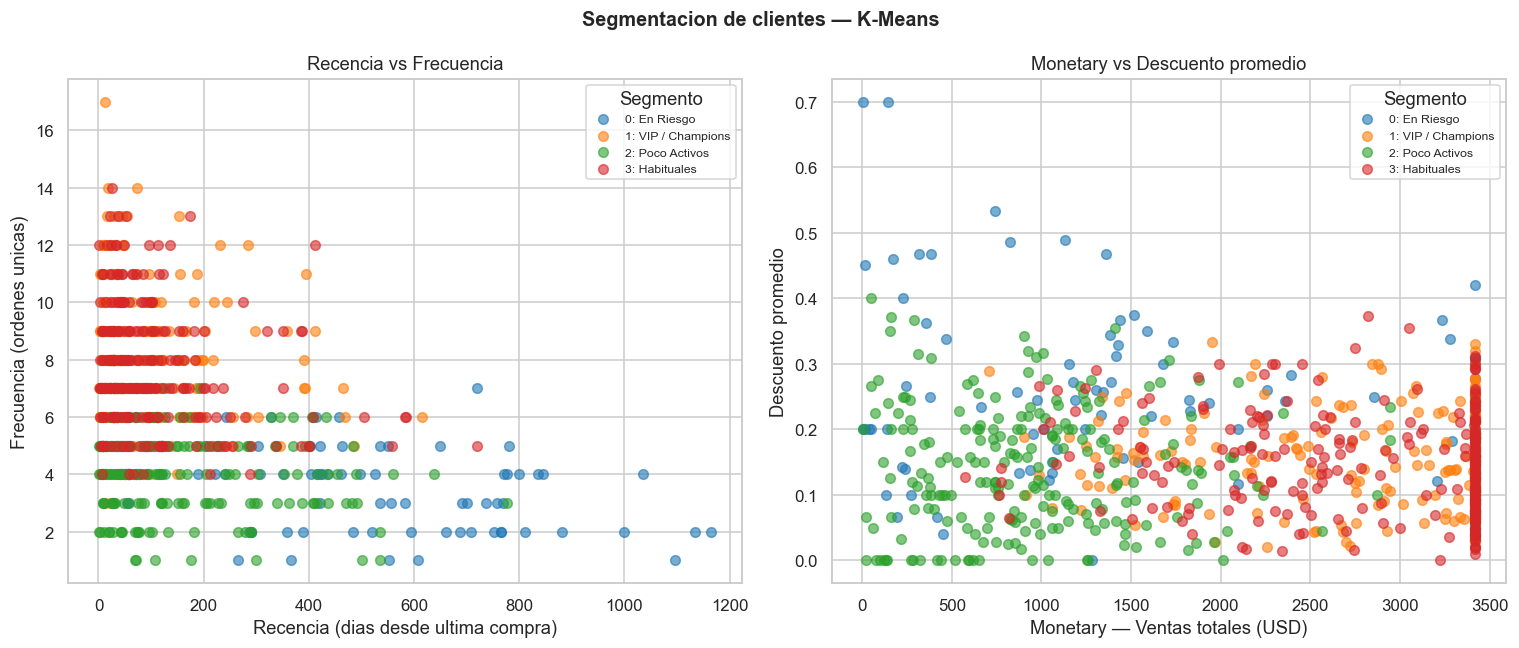

In [22]:
# ── Scatter: Recency vs Frequency coloreado por segmento ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Segmentacion de clientes — K-Means', fontsize=13, fontweight='bold')

palette = sns.color_palette('tab10', K_OPTIMO)
seg_names = {0: 'En Riesgo', 1: 'VIP / Champions', 2: 'Poco Activos', 3: 'Habituales'}
for seg in sorted(df_flat['segment'].unique()):
    mask = df_flat['segment'] == seg
    name = seg_names[seg]
    axes[0].scatter(df_flat[mask]['recency'], df_flat[mask]['frequency'],
                    alpha=0.6, s=40, label=f'{seg}: {name}', color=palette[seg])

axes[0].set_xlabel('Recencia (dias desde ultima compra)')
axes[0].set_ylabel('Frecuencia (ordenes unicas)')
axes[0].set_title('Recencia vs Frecuencia')
axes[0].legend(fontsize=8, title='Segmento')

for seg in sorted(df_flat['segment'].unique()):
    mask = df_flat['segment'] == seg
    name = seg_names[seg]
    axes[1].scatter(df_flat[mask]['monetary'], df_flat[mask]['avg_discount'],
                    alpha=0.6, s=40, label=f'{seg}: {name}', color=palette[seg])

axes[1].set_xlabel('Monetary — Ventas totales (USD)')
axes[1].set_ylabel('Descuento promedio')
axes[1].set_title('Monetary vs Descuento promedio')
axes[1].legend(fontsize=8, title='Segmento')

plt.tight_layout()
plt.savefig('../outputs/seg_03_scatter_segmentos.png', bbox_inches='tight')
plt.show()


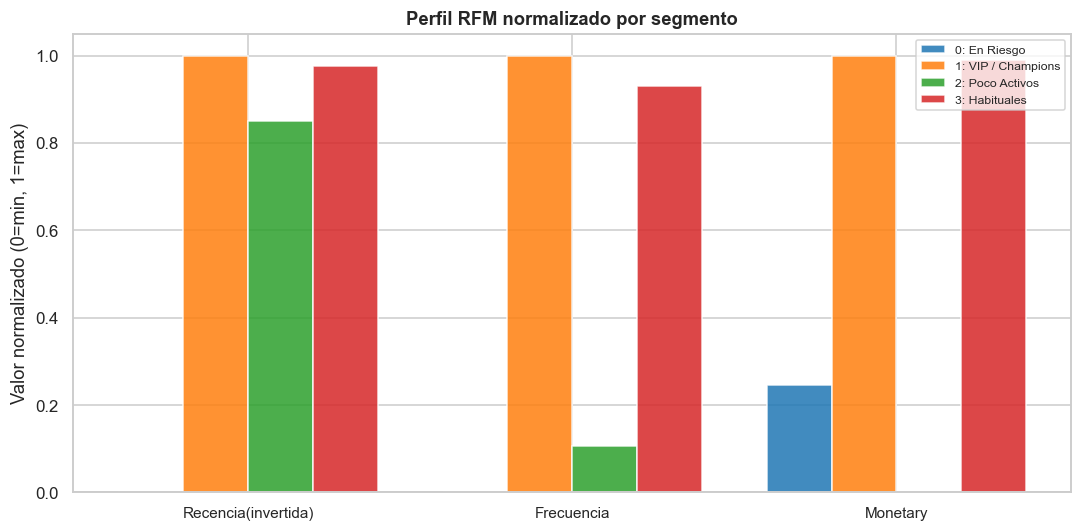

In [23]:
# ── Barras: perfil por segmento (variables RFM normalizadas) ─────────────────
rfm_vars = ['recency', 'frequency', 'monetary']
rfm_norm  = (profile[rfm_vars] - profile[rfm_vars].min()) / (profile[rfm_vars].max() - profile[rfm_vars].min() + 1e-9)
# Invert recency (menor recencia = mejor)
rfm_norm['recency'] = 1 - rfm_norm['recency']
rfm_norm.rename(columns={'recency': 'recencia_inv'}, inplace=True)

x      = np.arange(len(rfm_norm.columns))
width  = 0.8 / K_OPTIMO
fig, ax = plt.subplots(figsize=(10, 5))

for i, seg in enumerate(rfm_norm.index):
    ax.bar(x + i * width, rfm_norm.loc[seg], width, label=f'{seg}: {seg_names[seg]}',
           color=palette[seg], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * (K_OPTIMO - 1) / 2)
ax.set_xticklabels(['Recencia(invertida)', 'Frecuencia', 'Monetary'], fontsize=10)
ax.set_title('Perfil RFM normalizado por segmento', fontweight='bold')
ax.set_ylabel('Valor normalizado (0=min, 1=max)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/seg_04_rfm_barras.png', bbox_inches='tight')
plt.show()


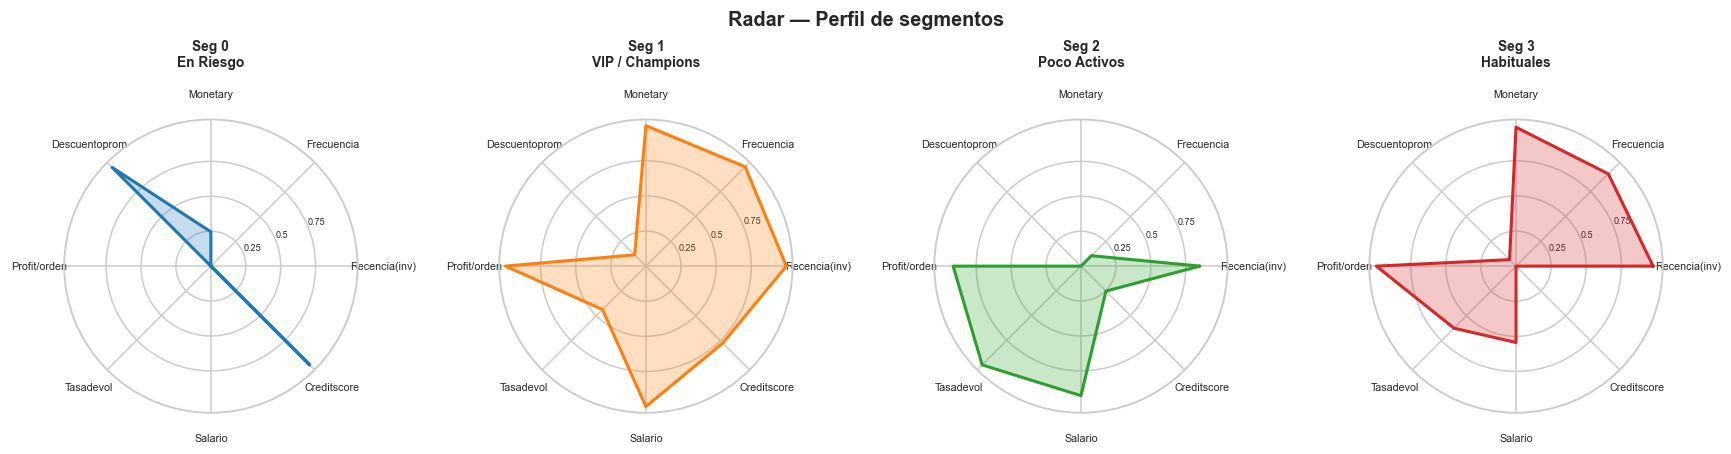

In [24]:
# ── Spider / Radar chart — perfil completo ───────────────────────────────────
from matplotlib.patches import FancyArrowPatch

RADAR_VARS = ['recency','frequency','monetary','avg_discount',
              'avg_profit_per_order','return_rate','monthly_salary','credit_score']

# Normalizar (recency invertida: menor es mejor)
radar_data = profile[RADAR_VARS].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)
radar_norm['recency'] = 1 - radar_norm['recency']
LABELS = ['Recencia(inv)','Frecuencia','Monetary','Descuentoprom',
          'Profit/orden','Tasadevol','Salario','Creditscore']

N      = len(RADAR_VARS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPTIMO, figsize=(4 * K_OPTIMO, 4),
                          subplot_kw=dict(polar=True))
fig.suptitle('Radar — Perfil de segmentos', fontsize=13, fontweight='bold')

if K_OPTIMO == 1:
    axes = [axes]

for ax, seg in zip(axes, sorted(df_flat['segment'].unique())):
    vals = radar_norm.loc[seg].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=palette[seg], linewidth=2)
    ax.fill(angles, vals, color=palette[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS, fontsize=7)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.5','0.75'], fontsize=6)
    ax.set_title(f'Seg {seg}\n{seg_names[seg]}', fontsize=9, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/seg_05_radar.png', bbox_inches='tight')
plt.show()


In [25]:
# ── Tabla resumen para la presentacion ──────────────────────────────────────
summary = df_flat.groupby(['segment','segment_name']).agg(
    n_clientes       = ('Customer_ID',        'count'),
    recencia_media   = ('recency',            'mean'),
    frecuencia_media = ('frequency',          'mean'),
    monetary_medio   = ('monetary',           'mean'),
    descuento_medio  = ('avg_discount',       'mean'),
    profit_medio     = ('avg_profit_per_order','mean'),
    tasa_devolucion  = ('return_rate',        'mean'),
    salario_medio    = ('monthly_salary',     'mean'),
    edad_media       = ('age',                'mean'),
    credit_medio     = ('credit_score',       'mean'),
).round(2).reset_index()

print("TABLA RESUMEN DE SEGMENTOS")
print("=" * 80)
print(summary.to_string(index=False))


TABLA RESUMEN DE SEGMENTOS
 segment    segment_name  n_clientes  recencia_media  frecuencia_media  monetary_medio  descuento_medio  profit_medio  tasa_devolucion  salario_medio  edad_media  credit_medio
       0       En Riesgo          83        467.6700            3.7000       1448.3800           0.2600      -89.2000           0.0400      5313.6600     37.9400      586.5100
       1 VIP / Champions         233         89.0900            7.9700       2837.2400           0.1500       39.3700           0.0600      6297.0100     38.6300      575.7900
       2    Poco Activos         226        145.8900            4.1500        996.2000           0.1400       28.4700           0.1000      6225.6800     37.2500      551.0200
       3      Habituales         262         97.9100            7.6700       2817.5800           0.1500       38.7000           0.0700      5848.6800     38.1100      539.0100


### 4.5 Exportar segmentos a CSV y MariaDB

In [26]:
# CSV
df_flat[['Customer_ID','segment','segment_name']].to_csv(
    '../outputs/segmentos_clientes.csv', index=False)
print('Guardado: outputs/segmentos_clientes.csv')

df_flat.to_csv('../data/processed/flat_table_model.csv', index=False)
print('Guardado: data/processed/flat_table_model.csv')

# MariaDB — tabla de segmentos
df_flat[['Customer_ID','segment','segment_name']].to_sql(
    'customer_segments', engine, if_exists='replace', index=False)
print('Cargado: customer_segments')

# MariaDB — flat table completa (incluye segment y segment_name)
df_flat.to_sql('customer_flat_table', engine, if_exists='replace',
               index=False, chunksize=200)
print('Cargado: customer_flat_table')

# Sincronizar nombres en tablas ML si existen
seg_names = df_flat[['segment','segment_name']].drop_duplicates().set_index('segment')['segment_name'].to_dict()
for tabla in ['ml_recommendations', 'ml_discount_optimization']:
    try:
        with engine.connect() as conn:
            for seg, nombre in seg_names.items():
                conn.execute(text(f'UPDATE {tabla} SET segment_name=:n WHERE segment=:s'),
                             {'n': nombre, 's': int(seg)})
            conn.commit()
        print(f'Actualizada: {tabla}')
    except Exception as e:
        print(f'{tabla} no encontrada (ejecutar Fase 5 primero): {e}')

print('\nSegmentos exportados y MariaDB sincronizado.')
print('Actualiza Power BI: Inicio -> Actualizar')

Guardado: outputs/segmentos_clientes.csv
Guardado: data/processed/flat_table_model.csv
Cargado: customer_segments
Cargado: customer_flat_table
Actualizada: ml_recommendations
Actualizada: ml_discount_optimization

Segmentos exportados y MariaDB sincronizado.
Actualiza Power BI: Inicio -> Actualizar


## Resumen final — Fases 3 y 4

| Entregable | Estado |
|---|---|
| 15 features por cliente (RFM + conductuales + socioeconomicas) | Construido |
| Tabla plana exportada a CSV y MariaDB | Exportado |
| K optimo determinado (Elbow + Silhouette) | Calculado |
| K-Means entrenado e interpretado | Completado |
| Segmentos nombrados con criterio de negocio | Completado |
| 5 graficas de segmentos generadas | Generadas |
| outputs/segmentos_clientes.csv listo para EDA pendiente | Listo |

**Siguiente paso:**
1. Volver a `02_EDA.ipynb` y ejecutar el Bloque 2.3 pendiente (analisis por segmento).
2. Continuar con `04_modelo_ml.ipynb` — Fase 5 (optimizacion de descuentos con ML).
